# Detecting alcohol references in superimposed image text

**DoubleVerify DS home assignment: CV + NLP.**

This notebook is the report. It covers the data exploration, the pipeline design and why each part was chosen, the metrics, the model selection, the test results, failure cases, and what to do next. Every number and chart below is computed live from the OCR cache and the saved train/test split.

**Summary**

* The images contain **templated ad captions** ("Don't miss limited edition nightlife **bourbon** event"). The template words appear in both classes; the label is decided by the **product word**.
* The text is deliberately **hard to read**: mirrored, upside-down, tilted, leetspeak ("v0dka"), and broken apart ("ch4mpa gne"). OCR quality, not the classifier, is the main limit on accuracy.
* **Pipeline:** EasyOCR on up to 8 orientations of each image → pick the orientation that reads as real words → clean the text → character n-grams plus alcohol word-list features → logistic regression.
* **Held-out test set (240 images):** F1 **0.87**, accuracy **0.86**, PR-AUC **0.96**. The word-list rule alone gets precision 0.99 but recall only 0.68.
* **Main failure:** images where OCR recovers no product word at all (thin, script or low-contrast fonts). About 17% of images give no recognisable words, and those are close to a coin flip (46% alcohol). No text classifier can fix them.
* **Dataset artifact to watch:** some template words appear in only one class ("looking for", "enjoy" only in non-alcohol captions). The model partly exploits this, and it may not carry over to the unseen set.

In [1]:
import sys
# This notebook needs the project's virtualenv; fail early with a clear message.
try:
    import cv2, rapidfuzz, sklearn  # noqa: F401
except ImportError as e:
    raise ImportError(
        f"{e} -- this kernel runs {sys.executable}. Switch the kernel to the project's "
        "'.venv' (VS Code: kernel picker, top right -> Python Environments -> .venv), "
        "or install the dependencies: pip install -r requirements.txt"
    ) from None

import json, re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# Find the project root (the folder holding alcohol_clf/) from wherever the kernel starts.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "alcohol_clf").is_dir())
sys.path.insert(0, str(ROOT))
from alcohol_clf.config import DATA_DIR, REPORTS_DIR, SEED
from alcohol_clf.data import load_cache
from alcohol_clf.features import LexiconFeatures
from alcohol_clf.lexicon import ALCOHOL_TERMS, NON_ALCOHOL_TERMS, match_terms
from alcohol_clf.metrics import best_f1_threshold, summarize
from alcohol_clf.model import build_pipeline
from alcohol_clf.select import conf_mass, rank_variants, variant_text, word_mass
from alcohol_clf.text_norm import normalize

FIG_DIR = REPORTS_DIR / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)
import warnings; warnings.filterwarnings("ignore")

# Chart style: recessive axes and grid, ink-colored text; class identity via two
# fixed palette slots (validated categorical slots 1-2), always with a legend or label.
ALC, NON, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
CLASS_COLOR = {"alcohol": ALC, "non_alcohol": NON}
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "font.size": 10, "legend.frameon": False, "lines.linewidth": 2,
})
def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

cache = load_cache(ROOT / "cache" / "ocr_raw.jsonl")
split = json.loads((REPORTS_DIR / "split.json").read_text())
metrics = json.loads((REPORTS_DIR / "metrics.json").read_text())
files = sorted(cache)
print(f"{len(files)} images in the OCR cache; train={len(split['train'])}, test={len(split['test'])}")

1200 images in the OCR cache; train=960, test=240


## 1. The data

* 1,200 JPEG images in two folders: `alcohol/` (600) and `non_alcohol/` (600). The classes are **perfectly balanced**, so accuracy is meaningful, though precision and recall are still reported separately.
* Each image is a natural photo with a short caption **superimposed** on it. The caption is the only thing that decides the label; the photo itself is unrelated (a teddy bear can carry "bourbon").
* **Leak to avoid:** the file names encode the label (`0000a.jpg` vs `0000na.jpg`). The pipeline never reads file names; `predict.py` uses pixels only.

The cell below builds one table row per image: the chosen OCR orientation, the chosen text, and how readable it is. The rest of the exploration uses this table.

In [2]:
rows = []
for f in files:
    rec = cache[f]
    ranked = rank_variants(rec["ocr"])
    best = ranked[0][1]
    text = variant_text(best)
    rows.append({
        "file_name": f, "label": rec["label"],
        "variant": best["variant"],
        "n_variants": len(rec["ocr"]),
        "text": text, "norm": normalize(text),
        "words": word_mass(text),                    # chars in recognisable words
        "mean_conf": np.mean([d["conf"] for d in best["dets"]]) if best["dets"] else 0.0,
        "alc_hits": sorted(match_terms(text, ALCOHOL_TERMS, negate=True)),
        "non_hits": sorted(match_terms(text, NON_ALCOHOL_TERMS)),
    })
df = pd.DataFrame(rows)
df["split"] = np.where(df.file_name.isin(split["test"]), "test", "train")
df["orientation"] = df.variant.str.replace("deskew_", "tilted + ", regex=False)
df[["file_name", "label", "orientation", "text", "alc_hits"]].sample(8, random_state=1)

,file_name,label,orientation,text,alc_hits
636,0318a.jpg,alcohol,orig,,[]
683,0341na.jpg,non_alcohol,hflip,HFX BW,[]
1033,3016na.jpg,non_alcohol,orig,VEEXss bar macha ARENSBERG PRUETT Funeral Home,[]
190,0095a.jpg,alcohol,hflip,stella artois,"[artois, stella, stella artois]"
1083,3041na.jpg,non_alcohol,vflip,Mln Eileieiorot;Al,[]
283,0141na.jpg,non_alcohol,hflip,Looking for party eneroy drnk resenve,[]
817,0408na.jpg,non_alcohol,orig,espresso check,[]
314,0157a.jpg,alcohol,orig,Check out celebration disco U nt stella arto i...,"[artois, stella, stella artois]"


### 1.1 Examples, one per distortion type

Each image was read in 4 flips (original / mirrored / upside-down-mirrored / rotated 180°). When the text was tilted, the image was also deskewed and read in the same 4 flips. Below is one example per orientation that won the selection, with the text the pipeline read.

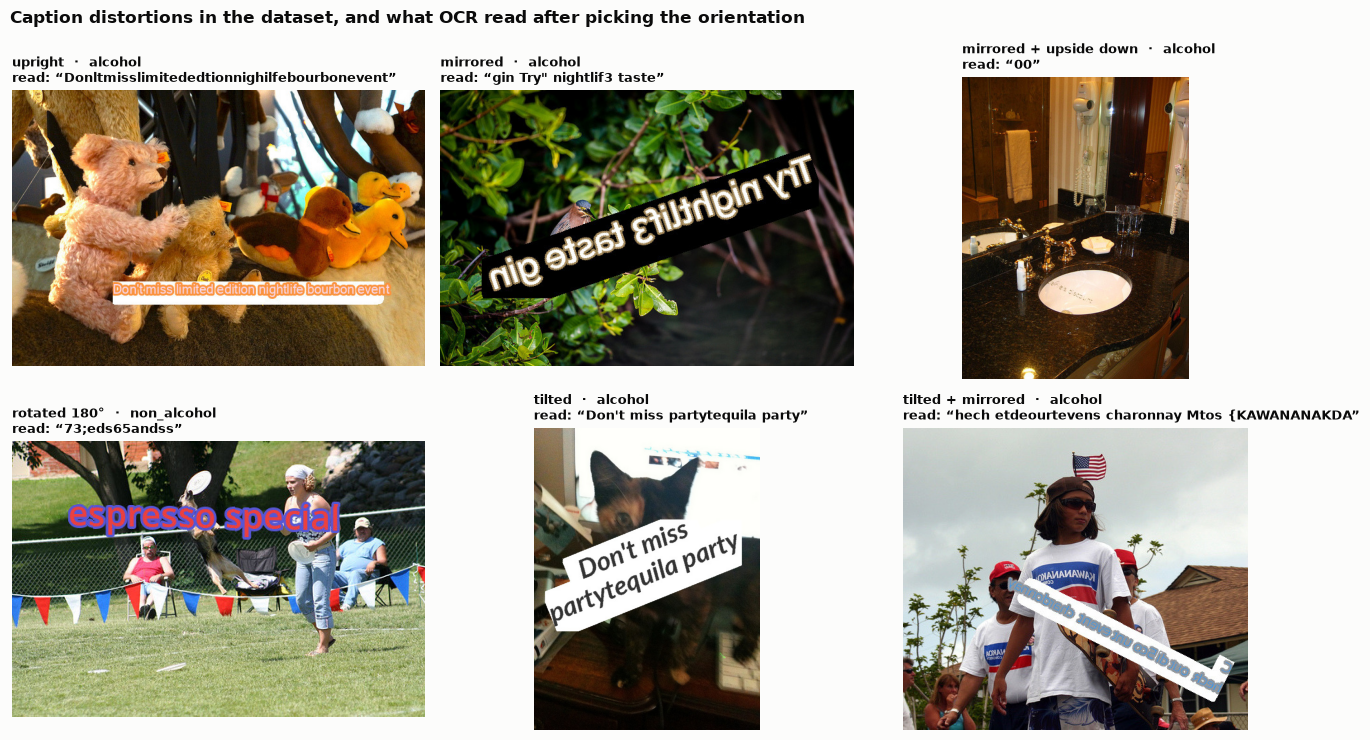

In [3]:
def show(ax, f, title):
    label = cache[f]["label"]
    ax.imshow(Image.open(DATA_DIR / label / f).convert("RGB"))
    ax.set_title(title, fontsize=9, loc="left", color=INK)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)

order = ["orig", "hflip", "vflip", "rot180", "deskew_orig", "deskew_hflip"]
names = {"orig": "upright", "hflip": "mirrored", "vflip": "mirrored + upside down",
         "rot180": "rotated 180°", "deskew_orig": "tilted", "deskew_hflip": "tilted + mirrored"}
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
for ax, v in zip(axes.flat, order):
    pool = df[(df.variant == v) & (df.alc_hits.str.len() > 0)]
    pool = pool if len(pool) else df[df.variant == v]
    if not len(pool):
        ax.axis("off"); continue
    r = pool.iloc[0]
    show(ax, r.file_name, f"{names[v]}  ·  {r.label}\nread: “{r.text[:48]}”")
fig.suptitle("Caption distortions in the dataset, and what OCR read after picking the orientation",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(); save(fig, "examples_by_distortion")

### 1.2 How much text is recoverable, and in which orientation?

About 62% of images read best upright. About 22% read best **mirrored or upside down**, and 20% read best **after deskewing** (567 of 1,200 images had tilted text and got the extra pass). Without the orientation step, EasyOCR would read gibberish for roughly a third of the dataset. The classes are spread evenly across orientations, so orientation itself carries no label signal.

label,alcohol,non_alcohol,total
orientation,,,
orig,371,375,746
tilted + orig,96,95,191
hflip,80,78,158
tilted + hflip,19,21,40
vflip,18,12,30
rot180,12,17,29
tilted + rot180,2,2,4
tilted + vflip,2,0,2


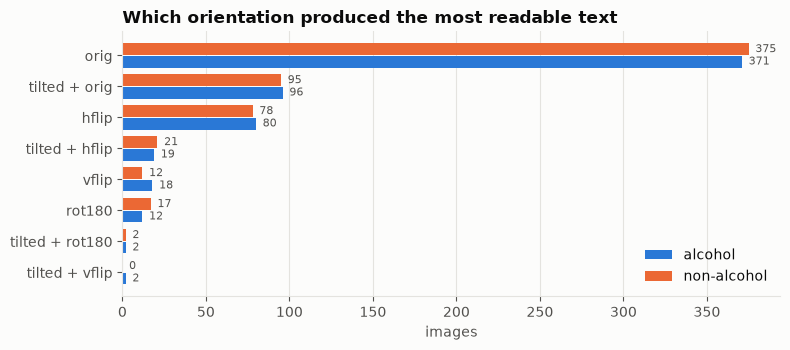

In [4]:
ct = df.groupby(["orientation", "label"]).size().unstack(fill_value=0)
ct = ct.loc[ct.sum(axis=1).sort_values().index]
fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(ct)); h = 0.38
for i, lab in enumerate(["alcohol", "non_alcohol"]):
    bars = ax.barh(y + (i - 0.5) * (h + 0.02), ct[lab], height=h, color=CLASS_COLOR[lab],
                   label=lab.replace("_", "-"))
    for b, v in zip(bars, ct[lab]):
        ax.text(b.get_width() + 4, b.get_y() + b.get_height() / 2, str(v),
                va="center", fontsize=8, color=INK2)
ax.set_yticks(y, ct.index); ax.set_xlabel("images"); ax.grid(axis="y", visible=False)
ax.set_title("Which orientation produced the most readable text")
ax.legend(loc="lower right"); fig.tight_layout(); save(fig, "orientation_by_class")
ct.assign(total=ct.sum(axis=1)).iloc[::-1]

### 1.3 The captions are templated, so the product word carries the label

Words found in the chosen text of at least 3% of one class's images:

In [5]:
def doc_freq(texts):
    c = Counter()
    for t in texts:
        c.update({w for w in t.split() if len(w) > 2})
    return c
freq = {lab: doc_freq(df[df.label == lab].norm) for lab in ["alcohol", "non_alcohol"]}
vocab = {w for c in freq.values() for w, n in c.items() if n >= 18}
wf = pd.DataFrame({lab: {w: freq[lab][w] for w in vocab} for lab in freq}).fillna(0).astype(int)
wf["share_alcohol"] = (wf.alcohol / (wf.alcohol + wf.non_alcohol)).round(2)
wf["kind"] = np.where(wf.share_alcohol.between(0.25, 0.75), "both classes",
             np.where(wf.share_alcohol > 0.75, "mostly alcohol", "mostly non-alcohol"))
wf.sort_values(["kind", "alcohol"], ascending=[True, False]).groupby("kind").head(12)

,alcohol,non_alcohol,share_alcohol,kind
check,82,43,0.66,both classes
try,58,32,0.64,both classes
miss,56,24,0.70,both classes
get,51,27,0.65,both classes
for,46,45,0.51,both classes
out,41,22,0.65,both classes
ready,40,26,0.61,both classes
don,36,18,0.67,both classes
bar,26,25,0.51,both classes
brew,25,26,0.49,both classes


**Reading the table:**

* "check", "try", "for", "bar", "menu" and **"brew"** show up in both classes. They come from the shared template and carry little signal; "brew" deliberately appears on tea and coffee too.
* The label comes from the product word: *beer, wine* (plus many alcohol words and brands, each too rare to reach the 3% cut: vodka, gin, rum, lager, heineken, stella artois…) versus *tea, espresso, water, energy drink, weed…* The alcohol vocabulary is **wide and thin**, which is why a curated word list adds value beyond what 960 training images can teach.
* **A template artifact:** "looking", "enjoy" and "hot" appear **only** in non-alcohol captions, and "don't miss" leans alcohol (70%). The two classes were generated with slightly different templates. A model trained on this data partly learns those templates (see §6). If the unseen set uses the same generator this helps; if not, it is a risk. The word-list features don't depend on it.
* The negative class includes other "vice" products (cannabis, weed). The task is alcohol specifically, not "adult content", which is why a generic "sensitive-content" signal would fail here.

### 1.4 Readability: the main bottleneck

`words` = number of characters of the chosen text that belong to recognisable words from the vocabulary (alcohol, non-alcohol and template words together, so the measure favours neither class). Among images **without** a word-list hit, the less readable the text, the closer the label is to a coin flip:

images  share_alcohol
strict_hit readability                       
False      no words        193          0.456
           1–4 chars        68          0.368
           5–8 chars       171          0.281
           > 8 chars       383          0.144
True       no words          9          1.000
           1–4 chars        15          1.000
           5–8 chars        51          1.000
           > 8 chars       310          0.997

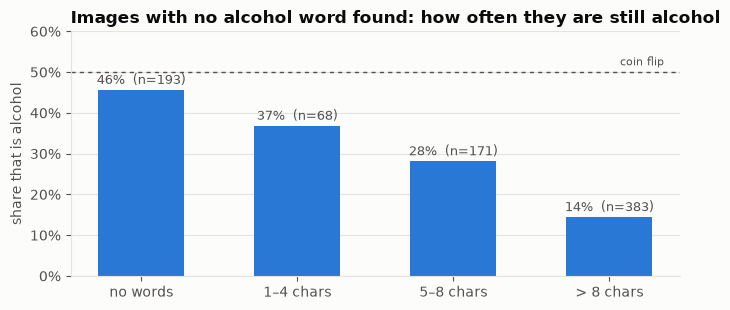

In [6]:
df["readability"] = pd.cut(df.words, [-1, 0, 4, 8, 1000],
                           labels=["no words", "1–4 chars", "5–8 chars", "> 8 chars"])
df["strict_hit"] = df.alc_hits.str.len() > 0
tab = (df.groupby(["strict_hit", "readability"], observed=True)
         .agg(images=("label", "size"), share_alcohol=("label", lambda s: (s == "alcohol").mean()))
         .round(3))
display(tab)

sub = tab.loc[False].reset_index()
fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.bar(sub.readability.astype(str), sub.share_alcohol, color=ALC, width=0.55)
for b, (s, n) in zip(bars, zip(sub.share_alcohol, sub.images)):
    ax.text(b.get_x() + b.get_width() / 2, s + 0.015, f"{s:.0%}  (n={n})",
            ha="center", fontsize=9, color=INK2)
ax.axhline(0.5, color=INK2, lw=1, ls=(0, (3, 3)))
ax.text(3.35, 0.51, "coin flip", fontsize=8, color=INK2, ha="right", va="bottom")
ax.set_ylim(0, 0.6); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylabel("share that is alcohol"); ax.grid(axis="x", visible=False)
ax.set_title("Images with no alcohol word found: how often they are still alcohol")
fig.tight_layout(); save(fig, "readability_vs_alcohol")

**What this shows:**

* When the strict word list finds an alcohol term, the image is alcohol **384 times out of 385**.
* When OCR recovers **no recognisable words** (193 images without a hit, 16% of the dataset), 46% are still alcohol. The caption is there, OCR just can't read it. These are the ceiling on what any text-only classifier can do.
* The more readable the text, the more confidently "no alcohol word found" means non-alcohol. The model gets this signal through the `sel_score` feature.

## 2. Pipeline design

```
image ─► OCR (EasyOCR, CPU) in up to 8 orientations
        (4 flips; +4 more after deskewing if the text is tilted)
      ─► pick the best orientation   (recognisable-word score + OCR confidence)
      ─► normalise the text          (accents, leetspeak 0→o 4→a $→s, punctuation, broken words)
      ─► features
           ├─ character 2–5-grams, TF-IDF         (partial credit for garbled words)
           └─ 9 word-list features                (strict hits, near-misses, readability)
      ─► logistic regression ─► P(alcohol) ≥ threshold ─► "alcohol" / "non_alcohol"
```

| Stage | Choice | Why |
|---|---|---|
| OCR | EasyOCR, CPU | Suggested in the brief; deterministic; its detector returns rotated text boxes, which are used to estimate tilt. |
| Orientations (flips, deskew) | Read every image several ways | EasyOCR only reads upright left-to-right text. About 25% of captions are mirrored or upside down (§1.2). |
| Choosing the orientation | Score = characters in recognisable words + 0.5 × confidence × length | Confidence alone picks confident gibberish. Recognisable words are a label-neutral signal of the right orientation. |
| Text cleaning | Leetspeak reversal, accent stripping, space-free "squashed" view | Handles "v0dka", "Moët" and "ch4mpa gne". |
| Word list | 76 generic alcohol words + 83 brands; non-alcohol look-alikes; negation masking | Domain knowledge; the model's decisions can be read off it; works on unseen brands and alcohol words that aren't in the training data. |
| Matching rules | ≤3 letters: exact word; 4–5: exact substring; ≥6: fuzzy (≥85) | Short words are ambiguous ("gin" ⊂ "ginger", "port" ⊂ "report"); long words survive OCR typos ("budweis?r"). |
| OCR letter confusions | rn↔m, vv↔w, l↔i, applied to both the term and the text | EasyOCR's most frequent confusions in this data ("charnpagne", "smimoff", "wlne"). |
| Negations | "non-alcoholic X", "alcohol free X", "virgin X", "root beer", "ginger ale" masked out | Not present in this data, but common in real ads; covered by unit tests. |
| Classifier | Logistic regression, `class_weight=balanced` | Small data, mostly word-level signal; its weights can be inspected; ties with random forest (§4.2). |

**Why not an end-to-end image model?** The label depends on *what the text says*, not on what the photo shows. Training a CNN on 1,200 photos would mostly learn the unrelated background. OCR followed by a text model focuses on the signal and handles unseen brands through the word list.

## 3. Metrics

**Final metrics** (positive class = alcohol):

* **F1**: the headline number. Precision and recall matter roughly equally here: a missed alcohol ad lets through brand-unsafe content, and a false flag blocks legitimate inventory.
* **Precision and recall** reported separately, because the right trade-off depends on the customer. A brand-safety buyer would take higher recall.
* **PR-AUC**: threshold-free, used to *select* the model. Picking the threshold is a separate step.
* **Accuracy**: meaningful here because the classes are balanced 50/50.

**Intermediate metrics** (diagnose which stage is failing; no ground-truth transcriptions exist):

* **OCR readability**: share of images whose chosen text contains recognisable words (§1.4).
* **Word-list precision and recall**: how often the rule-based stage is right when it fires, and how often it fires.
* **Orientation choice**: share of images where the chosen reading contains recognisable words. It rose from 74% to 79% after replacing "most confident" with the recognisable-word score.

**Protocol:** a stratified 80/20 split (seed 42). All model and threshold choices use 5-fold cross-validation on the 80%. The 20% test set is scored once at the end.

## 4. Model selection (cross-validation on the training split)

Three feature sets × a range of the regularization strength C. The combined model with the highest PR-AUC is selected; the threshold is the one that maximises out-of-fold F1.

,model,C,pr_auc,f1,precision,recall,threshold
0,lexicon_rule,NaN,0.8156,0.7739,1.0000,0.6312,0.5000
16,combined,10.0,0.9669,0.8906,0.8449,0.9417,0.3376
9,lexicon,3.0,0.9564,0.8580,0.8304,0.8875,0.4370
3,tfidf,3.0,0.9643,0.8940,0.8669,0.9229,0.5014


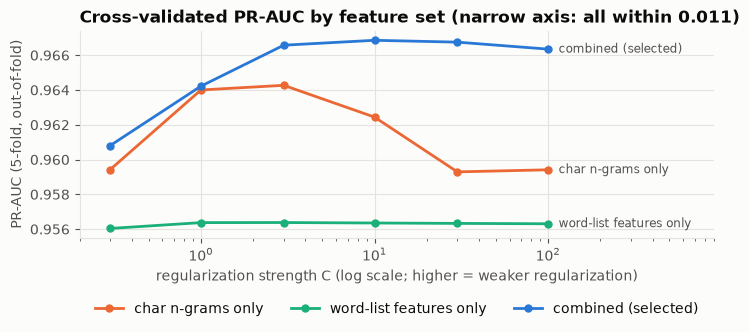

In [7]:
cv_df = pd.read_csv(REPORTS_DIR / "cv_results.csv")
best = cv_df.loc[cv_df[cv_df.model != "lexicon_rule"].groupby("model").pr_auc.idxmax()]
display(pd.concat([cv_df[cv_df.model == "lexicon_rule"], best])
        [["model", "C", "pr_auc", "f1", "precision", "recall", "threshold"]].round(4))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
series = {"tfidf": ("char n-grams only", NON), "lexicon": ("word-list features only", AQUA),
          "combined": ("combined (selected)", ALC)}
for kind, (name, color) in series.items():
    s = cv_df[cv_df.model == kind].sort_values("C")
    ax.plot(s.C, s.pr_auc, color=color, marker="o", ms=5, label=name)
    ax.text(s.C.iloc[-1] * 1.15, s.pr_auc.iloc[-1], name, color=INK2, fontsize=8.5, va="center")
ax.set_xscale("log"); ax.set_xlim(0.2, 900)
ax.set_xlabel("regularization strength C (log scale; higher = weaker regularization)")
ax.set_ylabel("PR-AUC (5-fold, out-of-fold)")
ax.set_title("Cross-validated PR-AUC by feature set (narrow axis: all within 0.011)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=3)
fig.tight_layout(); save(fig, "cv_model_selection")

* **Character n-grams do most of the work.** The combined model adds only ~0.003 PR-AUC over n-grams alone, which is within cross-validation noise. It is kept because the word-list features generalise to brands that aren't in the training data. N-grams can only learn words they have seen, while the word list knows 83 brands and 76 generic alcohol words regardless of the training set.
* **The word-list-only model** is the most interpretable (9 features) and still reaches PR-AUC 0.956.

### 4.1 Threshold

The F1 curve is **flat** around its peak, so the "best" threshold is noisy. Across the C values in the grid, the tuned threshold moved between 0.34 and 0.55.

OOF F1 at chosen 0.338: 0.8906   at 0.5: 0.8868


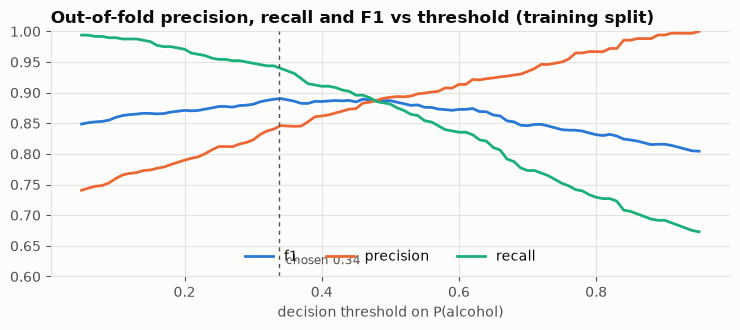

In [8]:
kind, C, thr = metrics["config"]["kind"], metrics["config"]["C"], metrics["config"]["threshold"]
tr = df.set_index("file_name").loc[split["train"]].reset_index()  # same order as train.py -> same folds
X_tr = [cache[f]["ocr"] for f in tr.file_name]; y_tr = (tr.label == "alcohol").astype(int).values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof = cross_val_predict(build_pipeline(kind, C), X_tr, y_tr, cv=cv, method="predict_proba")[:, 1]

grid = np.linspace(0.05, 0.95, 91)
curves = pd.DataFrame([summarize(y_tr, oof, t) for t in grid])
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for col, color in [("f1", ALC), ("precision", NON), ("recall", AQUA)]:
    ax.plot(grid, curves[col], color=color, label=col)
ax.axvline(thr, color=INK2, lw=1, ls=(0, (3, 3)))
ax.text(thr + 0.01, 0.62, f"chosen {thr:.2f}", fontsize=8.5, color=INK2)
ax.set_ylim(0.6, 1.0); ax.set_xlabel("decision threshold on P(alcohol)")
ax.set_title("Out-of-fold precision, recall and F1 vs threshold (training split)")
ax.legend(loc="lower center", ncol=3); fig.tight_layout(); save(fig, "threshold_curve")
print(f"OOF F1 at chosen {thr:.3f}: {summarize(y_tr, oof, thr)['f1']:.4f}   at 0.5: {summarize(y_tr, oof, 0.5)['f1']:.4f}")

### 4.2 Would a random forest do better?

The same features and the same folds, with the classifier swapped:

In [9]:
def cv_row(name, pipe):
    p = cross_val_predict(pipe, X_tr, y_tr, cv=cv, method="predict_proba")[:, 1]
    m = summarize(y_tr, p, best_f1_threshold(y_tr, p))
    return {"model": name, **{k: round(m[k], 4) for k in ["pr_auc", "roc_auc", "f1", "precision", "recall"]}}

rf_rows = [cv_row(f"LogReg {kind} C={C:g}", build_pipeline(kind, C))]
for feats in ["combined", "tfidf", "lexicon"]:
    p = build_pipeline(feats, 1.0)
    p.steps[-1] = ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                   class_weight="balanced", n_jobs=-1, random_state=SEED))
    rf_rows.append(cv_row(f"RandomForest {feats}", p))
pd.DataFrame(rf_rows)

,model,pr_auc,roc_auc,f1,precision,recall
0,LogReg combined C=10,0.9669,0.9643,0.8906,0.8449,0.9417
1,RandomForest combined,0.9673,0.9655,0.8905,0.8832,0.8979
2,RandomForest tfidf,0.9466,0.9479,0.8771,0.8426,0.9146
3,RandomForest lexicon,0.9546,0.9509,0.8640,0.7996,0.9396


**It's a tie.** Random forest on the combined features is within a few thousandths of logistic regression, smaller than the ~0.02 F1 gap between cross-validation and test scores (§5), so the difference is noise. Random forest does **worse** on character n-grams alone, because thousands of sparse columns suit a linear model, not trees. It only catches up by leaning on the 9 word-list features.

Logistic regression is kept because it is **easy to explain** (§6 reads its weights directly), gives **smoother, better-behaved probabilities** (which matters when tuning a threshold), and is **small and fast**. The bottleneck is OCR, not the classifier. Both models fail on the same unreadable images.

## 5. Test-set results (240 held-out images, scored once)

The model analysed here is **trained on the 80% training split only**, so the test images are unseen. The shipped `models/model.joblib` is retrained on all 1,200 images with the same settings.

In [10]:
te = df.set_index("file_name").loc[split["test"]].reset_index()
X_te = [cache[f]["ocr"] for f in te.file_name]; y_te = (te.label == "alcohol").astype(int).values
model = build_pipeline(kind, C).fit(X_tr, y_tr)
te["prob"] = model.predict_proba(X_te)[:, 1]
te["pred"] = np.where(te.prob >= thr, "alcohol", "non_alcohol")

# Sanity check: identical to the predictions train.py wrote.
saved = pd.read_csv(REPORTS_DIR / "test_predictions.csv").set_index("file_name")
assert np.allclose(saved.loc[te.file_name, "prob_alcohol"].values, te.prob.values)

rule = te.alc_hits.str.len().gt(0).astype(float).values
res = pd.DataFrame({
    "word-list rule (no training)": summarize(y_te, rule),
    f"model @ {thr:.2f} (shipped threshold)": summarize(y_te, te.prob, thr),
    "model @ 0.50": summarize(y_te, te.prob, 0.5),
}).T[["precision", "recall", "f1", "accuracy", "pr_auc", "tp", "fp", "fn", "tn"]]
missed_by_rule = (te.label == "alcohol") & (rule == 0)
print(f"alcohol images the word-list rule misses: {missed_by_rule.sum()}; "
      f"the model recovers {(missed_by_rule & (te.pred == 'alcohol')).sum()} of them")
res.style.format({c: "{:.3f}" for c in ["precision", "recall", "f1", "accuracy", "pr_auc"]})

alcohol images the word-list rule misses: 39; the model recovers 29 of them


,precision,recall,f1,accuracy,pr_auc,tp,fp,fn,tn
word-list rule (no training),0.988,0.675,0.802,0.833,0.829,81.000000,1.000000,39.000000,119.000000
model @ 0.34 (shipped threshold),0.827,0.917,0.870,0.863,0.961,110.000000,23.000000,10.000000,97.000000
model @ 0.50,0.875,0.875,0.875,0.875,0.961,105.000000,15.000000,15.000000,105.000000


,predicted alcohol,predicted non-alcohol
true alcohol,110,10
true non-alcohol,23,97


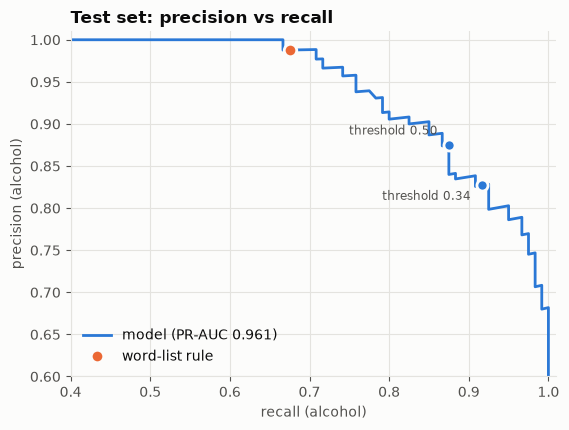

In [11]:
m = summarize(y_te, te.prob, thr)
cm = pd.DataFrame([[m["tp"], m["fn"]], [m["fp"], m["tn"]]],
                  index=["true alcohol", "true non-alcohol"],
                  columns=["predicted alcohol", "predicted non-alcohol"])
display(cm)

prec, rec, _ = precision_recall_curve(y_te, te.prob)
fig, ax = plt.subplots(figsize=(5.8, 4.4))
ax.plot(rec, prec, color=ALC, label=f"model (PR-AUC {m['pr_auc']:.3f})")
r0 = summarize(y_te, rule)
ax.plot(r0["recall"], r0["precision"], "o", ms=9, color=NON, mec=SURF, mew=2, label="word-list rule")
for t, dy in [(thr, -0.035), (0.5, 0.025)]:
    mt = summarize(y_te, te.prob, t)
    ax.plot(mt["recall"], mt["precision"], "o", ms=8, color=ALC, mec=SURF, mew=2)
    ax.annotate(f"threshold {t:.2f}", (mt["recall"], mt["precision"]), xytext=(-8, dy * 300),
                textcoords="offset points", ha="right", fontsize=8.5, color=INK2)
ax.set_xlim(0.4, 1.01); ax.set_ylim(0.6, 1.01)
ax.set_xlabel("recall (alcohol)"); ax.set_ylabel("precision (alcohol)")
ax.set_title("Test set: precision vs recall"); ax.legend(loc="lower left")
fig.tight_layout(); save(fig, "test_pr_curve")

**Reading the results:**

* The model catches what the word list catches, and also **recovers most of the alcohol images the rule misses** (count printed above; recall 0.68 → 0.92). The price is precision: 0.99 → 0.83. Nearly all of the new false alarms are unreadable images near P = 0.5 (§7).
* **Cross-validation F1 was 0.89; test F1 is 0.87.** A gap of that size is normal for 240 test images; one image is worth about 0.4% accuracy.
* **Threshold choice:** on this test set, 0.5 happens to score a little better (F1 0.875) than the tuned 0.34. Switching to 0.5 *because* of this would be tuning on the test set, so the tuned threshold is kept and the instability is reported instead.
* **Caveat, for honesty:** two small word-list fixes (the l↔i letter confusion, and requiring "brewery" as a whole word) were made after looking at test-set errors from the first model. They were then validated on training-split cross-validation, where PR-AUC rose slightly from 0.966 to 0.967. The test numbers above are therefore slightly optimistic.

## 6. Explainability: what the model relies on

Word-list features (standardized, so weights are comparable):


,weight
[non_soft],-1.67
[non_best],-1.52
[has_text],-0.28
[sel_margin],-0.17
[sel_score],-0.07
[alc_count],1.73
[alc_soft],1.91
[alc_best],1.98
[alc_runner_up],2.26


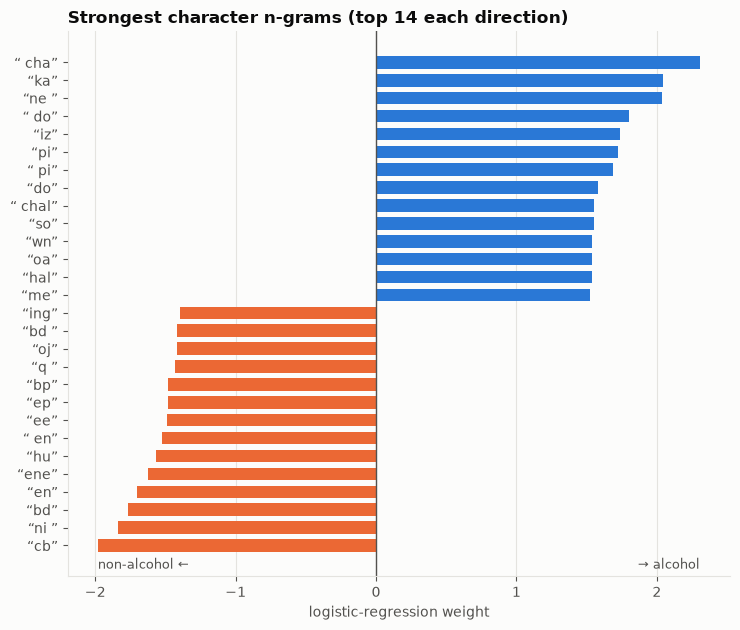

In [12]:
fu = model.named_steps["features"]
names = list(fu.transformer_list[0][1].named_steps["tfidf"].get_feature_names_out())
names += [f"[{n}]" for n in LexiconFeatures.FEATURE_NAMES]
coef = pd.Series(model.named_steps["clf"].coef_[0], index=names)
print("Word-list features (standardized, so weights are comparable):")
display(coef[[n for n in names if n.startswith("[")]].sort_values().round(2).to_frame("weight"))

k = 14
top = pd.concat([coef[~coef.index.str.startswith("[")].nlargest(k),
                 coef[~coef.index.str.startswith("[")].nsmallest(k)]).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 6.4))
colors = [ALC if v > 0 else NON for v in top]
ax.barh([f"“{n}”" for n in top.index], top.values, color=colors, height=0.7)
ax.axvline(0, color=INK2, lw=1); ax.grid(axis="y", visible=False)
ax.set_xlabel("logistic-regression weight")
ax.text(top.max(), -1.3, "→ alcohol", ha="right", color=INK2, fontsize=9)
ax.text(top.min(), -1.3, "non-alcohol ←", ha="left", color=INK2, fontsize=9)
ax.set_title(f"Strongest character n-grams (top {k} each direction)")
fig.tight_layout(); save(fig, "top_ngrams")

**Word-list features:** all four alcohol features push towards alcohol, and the two non-alcohol features push the other way. `alc_runner_up` (an alcohol word in the *second-best* orientation) has the largest weight. When the orientation choice is unsure, the other readings still carry evidence. Readability (`sel_score`) matters little once the other features are in.

**Character n-grams:** mostly short **fragments of product words**, e.g. "cha" (champagne, chardonnay), "ka" (vodka), "ne " (wine) versus "cb" (cbd), "ene" (energy), "ep" (espresso). Because they are fragments, a word with an OCR error still matches many of them. Some are **template artifacts**, for example " do" (from "don't", which leans alcohol in this data, §1.3) and "ing" (from "looking", only in non-alcohol captions). These help on this dataset but might not carry over.

## 7. Failure analysis

Every test error, sorted into a cause by rules:

In [13]:
err = te[te.label != te.pred].copy()
err["error"] = np.where(err.label == "alcohol", "missed alcohol (FN)", "false alarm (FP)")
def cause(r):
    if r.words == 0:
        return "no readable words"
    if r.error.startswith("false") and r.alc_hits:
        return "word list fired wrongly"
    if r.error.startswith("missed"):
        return "product word garbled / not read"
    return "readable, no product word found"
err["cause"] = err.apply(cause, axis=1)
display(err.groupby(["error", "cause"]).size().to_frame("images"))
err[["file_name", "label", "prob", "cause", "text"]].sort_values("prob").round(3)

images
error               cause                                  
false alarm (FP)    no readable words                    11
                    readable, no product word found      11
                    word list fired wrongly               1
missed alcohol (FN) no readable words                     3
                    product word garbled / not read       7

,file_name,label,prob,cause,text
69,0407a.jpg,alcohol,0.006,product word garbled / not read,Cexe Iorbar tea VI 'clnonney
202,0219a.jpg,alcohol,0.015,product word garbled / not read,Y premium $ moczh ginismooth
226,0421a.jpg,alcohol,0.069,product word garbled / not read,T Sn Offer Joy
160,0304a.jpg,alcohol,0.119,no readable words,mOFleny
207,0167a.jpg,alcohol,0.194,no readable words,D
198,0414a.jpg,alcohol,0.195,product word garbled / not read,Getteady forevenBl premiumlnnie waher
179,0401a.jpg,alcohol,0.251,product word garbled / not read,lag 7ry party flavor 8ss
29,3025a.jpg,alcohol,0.253,no readable words,OTCa ken
145,0475a.jpg,alcohol,0.255,product word garbled / not read,Gamnd 658590
70,0034a.jpg,alcohol,0.323,product word garbled / not read,cpeche poncmisg eminod Imperte)


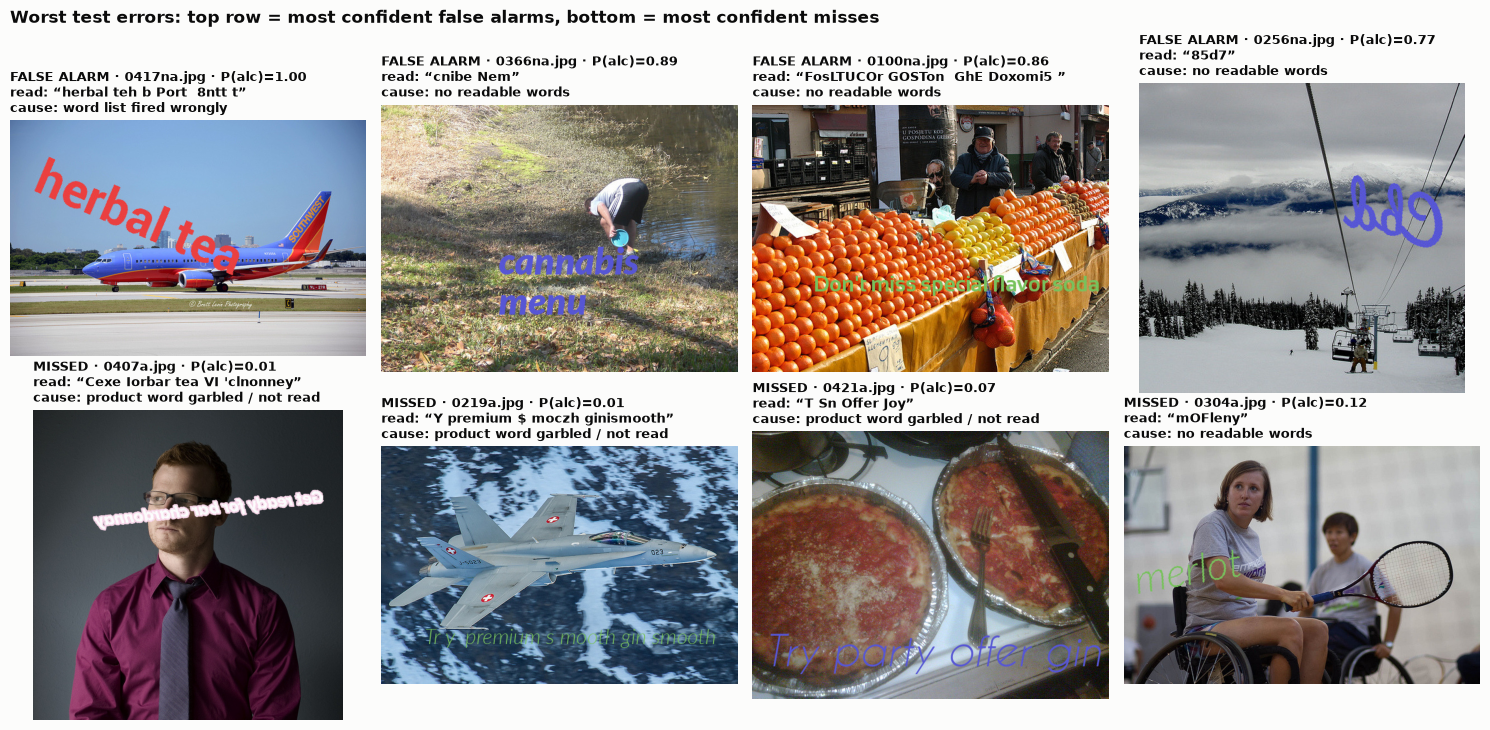

In [14]:
pick = pd.concat([err[err.error.str.startswith("false")].nlargest(4, "prob"),
                  err[err.error.str.startswith("missed")].nsmallest(4, "prob")])
fig, axes = plt.subplots(2, 4, figsize=(15, 7.4))
for ax, (_, r) in zip(axes.flat, pick.iterrows()):
    kind_ = "FALSE ALARM" if r.label == "non_alcohol" else "MISSED"
    show(ax, r.file_name, f"{kind_} · {r.file_name} · P(alc)={r.prob:.2f}\nread: “{r.text[:30]}”\ncause: {r.cause}")
fig.suptitle("Worst test errors: top row = most confident false alarms, bottom = most confident misses",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(); save(fig, "failure_cases")

**What goes wrong**

Looking at the images above (the caption is readable to a human in each case):

1. **OCR can't read the caption font (most errors).** Thin, script or low-contrast captions: "cannabis menu" in purple on grass → "cnibe Nem"; "cbd" in a script font → "85d7"; "merlot" in thin green → "mOFleny"; "Try party offer **gin**" → "T Sn Offer Joy". With no product word, a false alarm sits near P = 0.5–0.9 (driven by template n-grams), and a miss sits low. This is the coin-flip group from §1.4.
2. **Wrong orientation or partial reading.** A mirrored, tilted "Get ready for bar **chardonnay**" was read as "Cexe lorbar tea VI 'clnonney'". The recogniser invented "tea", a strong non-alcohol word.
3. **A short word stuck to the next one.** "smooth **gin** smooth" → "ginismooth". "gin" must be a separate word to avoid "ginger", so this is missed.
4. **Scene text, not the caption.** In 0417na the caption says "herbal tea", but OCR also read text on the aircraft and produced a "Port" token. This is the only strict word-list false hit on the test set. The task is about *superimposed* text, and the photo's own text is noise.

### Robustness by distortion type (test set)

In [15]:
te["correct"] = te.label == te.pred
rob = te.groupby("orientation").agg(images=("correct", "size"), accuracy=("correct", "mean"))
rob.loc["(no readable words)"] = [(te.words == 0).sum(), te[te.words == 0].correct.mean()]
rob.round(3).sort_values("images", ascending=False)

,images,accuracy
orientation,,
orig,150.0,0.893
tilted + orig,39.0,0.821
(no readable words),36.0,0.611
hflip,28.0,0.857
tilted + hflip,8.0,0.750
vflip,7.0,0.714
rot180,5.0,0.600
tilted + rot180,2.0,1.000
tilted + vflip,1.0,1.000


Upright (0.89), tilted (0.82) and mirrored (0.86) captions are classified at similar accuracy, so the orientation step does its job. The upside-down groups are too small here (5–7 images) to judge. Accuracy drops sharply when no readable words are recovered (0.61), which again points at OCR as the limit. Note the overlap: "(no readable words)" images also appear in their orientation row.

## 8. Limitations and next steps

**Known limitations**

* **OCR is the ceiling.** About 17% of images give no recognisable words. For these, a text-only pipeline is guessing.
* **Template artifacts.** Some template words are class-specific in this data (§1.3). The n-gram part of the model uses them.
* **Scene text** in the photo is read along with the caption and can trigger false hits (§7).
* **Test estimate is slightly optimistic** (see §5 caveat), and 240 images give a margin of roughly ±4% on accuracy.
* **The threshold is noisy** (§4.1). F1 is flat between about 0.35 and 0.55.
* **Short alcohol words stuck to a neighbour are missed** ("ginismooth"): "gin", "rum" and "ale" must be separate words to avoid "ginger", "drum" and "sale".
* **Unknown brands** outside the word list and the training vocabulary rely on the context words and n-grams only.
* **English only.** Nothing handles non-English alcohol words or scripts.
* **Speed:** about 2–3 s per image on CPU, mostly because each image is read in 4–8 orientations.

**Next steps, by expected value**

1. **Better OCR on hard captions.** Try PaddleOCR or a second OCR engine and combine their readings. Upscale and binarise small or low-contrast captions. Use the text detector's boxes to crop and re-read each caption line separately. Estimated effect: converts part of the coin-flip group into readable text.
2. **Use OCR's other candidate readings.** Ask the recogniser for its top-k character guesses per text box, instead of only its best guess, and match those against the word list.
3. **A small multilingual sentence-embedding model** on the cleaned text, for semantic generalisation to unseen brands and paraphrases ("single malt", "IPA night"). It runs fine on CPU.
4. **Smarter orientation choice:** combine the evidence from all orientations instead of picking one reading.
5. **Label-noise audit:** manually check the most confident errors to see whether some captions are unreadable even to a human.
6. **Speed-up:** skip the extra orientations when the upright reading already scores well (62% of images win upright).
7. **Separate caption from scene text:** superimposed captions are large, uniformly coloured and often on a band. Weighting text boxes by size and colour uniformity would suppress background text like the aircraft's.
8. **Reduce template reliance:** drop n-grams that come from template words, or augment the training text by swapping template phrases between classes, then check that CV holds.

## 9. Reproducing

```bash
pip install -r requirements.txt
python scripts/cache_ocr.py          # OCR the labelled images once (~45 min CPU)
python scripts/train.py              # split, CV, test, save models/model.joblib + reports/*
python -m pytest tests               # regression tests for text cleaning / matching
python predict.py --input-dir <dir>  # -> results.csv
python scripts/evaluate.py --results results.csv --labels-dir images
```